# Analysis
## GAMMA REGRESSION

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

## Merging ranking data and sampling data

In [200]:
attempt2 = pd.read_csv("attempt_2_numSampledFromDJs.csv")

In [201]:
attempt2_By = pd.read_csv("attempt_2_numSampledByDJs.csv")

In [202]:
allDjsNames = pd.read_csv("top100djs_by_year_cleaned_names.csv")

In [205]:
names = allDjsNames['DJ Name'].unique();
points = []
for name in names:
    data_point = {
        "DJ Name": name,
        "Mean Ranking": allDjsNames[allDjsNames['DJ Name'] == name]['Rank'].mean(),
        "Num Years": len(allDjsNames[allDjsNames['DJ Name'] == name]),
        "Num Sampled from":attempt2[attempt2['DJ Name'] == name]['Num Sampled'].iloc[0],
        "Num Sampled by":attempt2_By[attempt2_By['DJ Name'] == name]['Num Sampled By'].iloc[0],
    }
    points.append(data_point)

In [206]:
summary_raw_df = pd.DataFrame(points)
summary_raw_df

,DJ Name,Mean Ranking,Num Years,Num Sampled from,Num Sampled by
0,Tiësto,7.142857,21,53,43
1,Paul van Dyk,29.714286,21,5,11
2,Armin Van Buuren,2.952381,21,27,13
3,Sasha,16.250000,8,11,2
4,Ferry Corsten,47.285714,21,7,15
...,...,...,...,...,...
441,Mau P,91.000000,1,6,2
442,B Jones,94.000000,1,0,0
443,Giuseppe Ottaviani,98.000000,1,0,2
444,Faustix,99.000000,1,6,2


In [207]:
summary_raw_df.to_csv("merged_mean_rank_year_sampled_count.csv")

In [208]:
summary_raw_df = pd.read_csv("merged_mean_rank_year_sampled_count.csv")

# Bayesian Ranking
- Large number of DJs never made the charts, need to adjust ranking for these DJs

In [209]:
summary_raw_df['Num Years'].describe()

count    446.000000
mean       4.618834
std        4.170846
min        1.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       21.000000
Name: Num Years, dtype: float64

In [324]:
summary_raw_df['Num Sampled from'].describe()

count    446.000000
mean      10.818386
std       45.292316
min        0.000000
25%        0.000000
50%        1.000000
75%        6.000000
max      776.000000
Name: Num Sampled from, dtype: float64

In [326]:
summary_raw_df['Num Sampled by'].describe()

count     446.000000
mean       15.843049
std        67.321049
min         0.000000
25%         0.000000
50%         4.000000
75%        13.750000
max      1213.000000
Name: Num Sampled by, dtype: float64

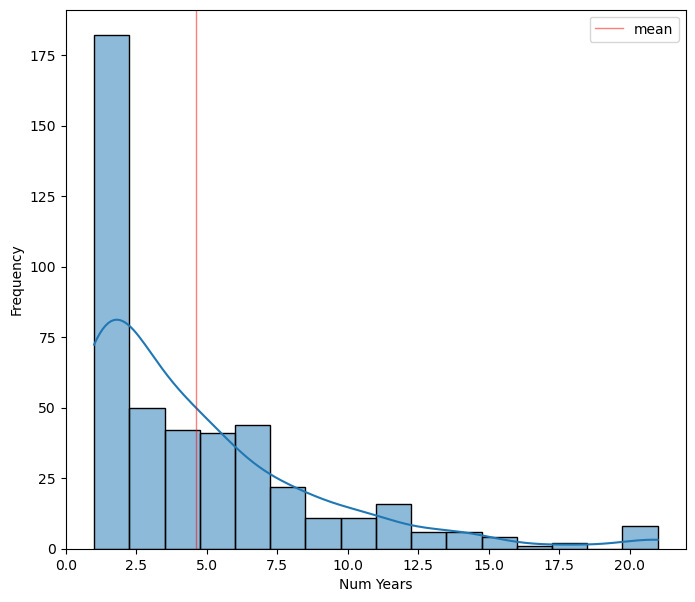

In [335]:
import seaborn as sns
plt.figure(figsize=(8, 7))
sns.histplot(data=summary_raw_df,x='Num Years',kde=True)
plt.axvline(x=summary_raw_df['Num Years'].mean(), linewidth=1, color='r', label="mean", alpha=0.5)
plt.ylabel('Frequency')
plt.legend()
plt.savefig("figures/Num_Years_Distribution.png")

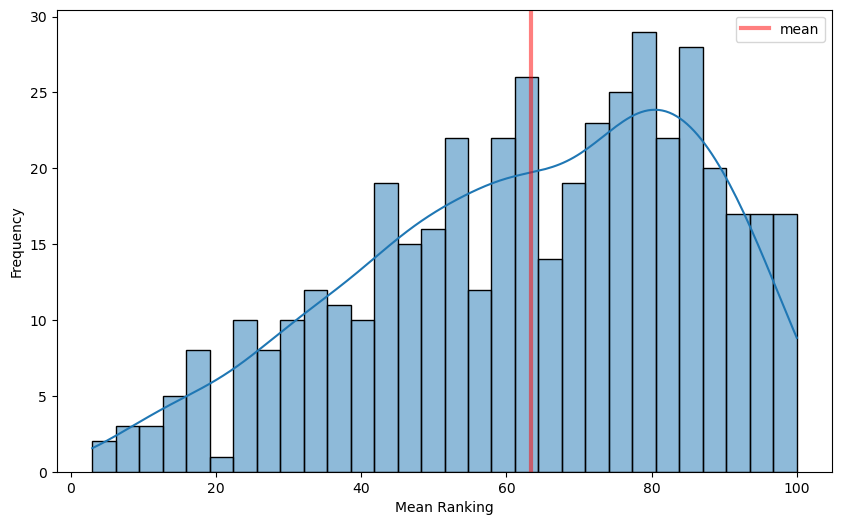

In [320]:
plt.figure(figsize=(10, 6))
sns.histplot(data=summary_raw_df,x='Mean Ranking',kde=True,bins=30)
plt.axvline(x=summary_raw_df['Mean Ranking'].mean(), linewidth=3, color='r', label="mean", alpha=0.5)
plt.ylabel('Frequency')
plt.legend()
plt.savefig("figures/Mean_Ranking_Distribution.png")

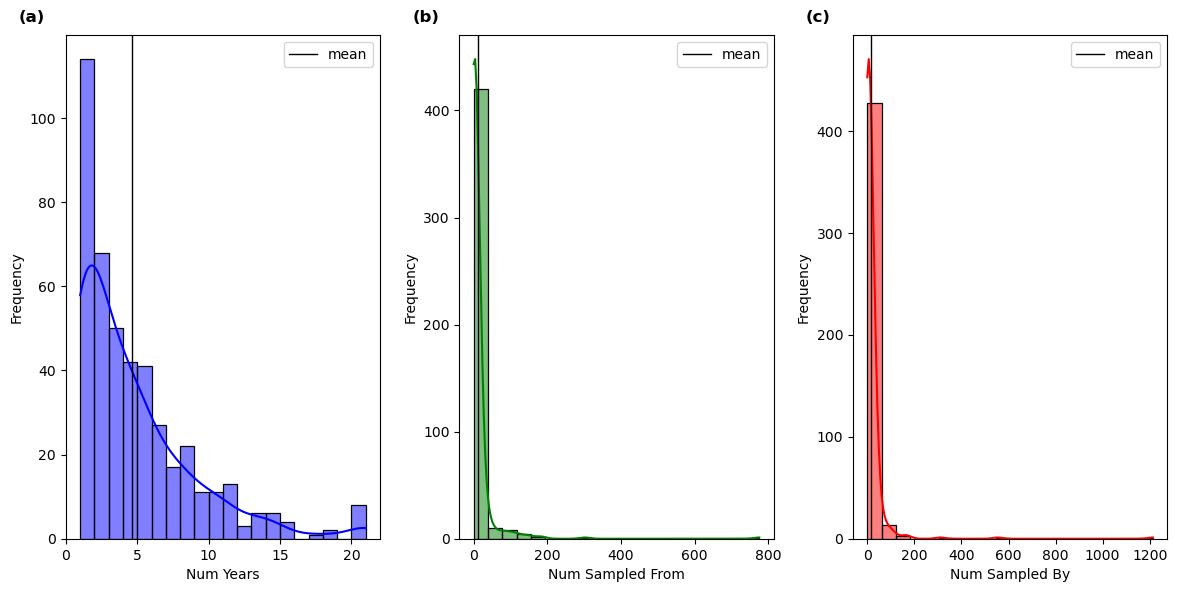

In [352]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assume you have your distributions as pandas Series or numpy arrays
# e.g., num_years_dist, num_sampled_from_dist, num_sampled_by_dist

# Create a figure with 3 subplots side by side
fig, axs = plt.subplots(1, 3, figsize=(12,6))  # 1 row, 3 columns

# Plot each distribution using seaborn
sns.histplot(data=summary_raw_df,x='Num Years', kde=True, ax=axs[0], color='blue', bins=20)
axs[0].set_xlabel('Num Years')
axs[0].set_ylabel('Frequency')
axs[0].axvline(x=summary_raw_df['Num Years'].mean(), linewidth=1, color='black', label="mean")
axs[0].legend()
axs[0].text(-0.15, 1.05, '(a)', transform=axs[0].transAxes, fontsize=12, fontweight='bold', va='top')

sns.histplot(data=summary_raw_df,x='Num Sampled from', kde=True, ax=axs[1], color='green', bins=20)
axs[1].set_xlabel('Num Sampled From')
axs[1].set_ylabel('Frequency')
axs[1].axvline(x=summary_raw_df['Num Sampled from'].mean(), linewidth=1, color='black', label="mean")
axs[1].legend()
axs[1].text(-0.15, 1.05, '(b)', transform=axs[1].transAxes, fontsize=12, fontweight='bold', va='top')

sns.histplot(data=summary_raw_df,x='Num Sampled by', kde=True,ax=axs[2], color='red', bins=20)
axs[2].set_xlabel('Num Sampled By')
axs[2].set_ylabel('Frequency')
axs[2].axvline(x=summary_raw_df['Num Sampled by'].mean(), linewidth=1, color='black', label="mean")
axs[2].legend()
axs[2].text(-0.15, 1.05, '(c)', transform=axs[2].transAxes, fontsize=12, fontweight='bold', va='top')

# Adjust layout to avoid overlapping text
plt.tight_layout()

# Show the figure
plt.savefig("figures/Feature_Distributions.png")


In [317]:
summary_raw_df['Bayesian Ranking'].describe()

count    446.000000
mean      53.943321
std       12.054174
min        8.818649
25%       48.455947
50%       57.254982
75%       61.953010
max       79.064757
Name: Bayesian Ranking, dtype: float64

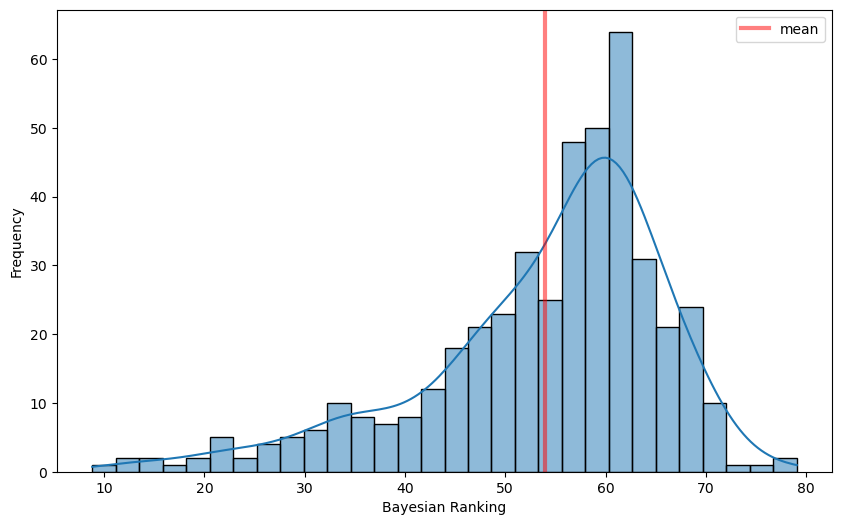

In [321]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

global_mean = allDjsNames.Rank.mean()
def bayesian_rank(row, C=3):
    R = row['Mean Ranking']  # mean of actual ranks when DJ was ranked
    v = row['Num Years']   # how many years they were ranked
    return ((v*R) + global_mean*C) / (v+C)
summary_raw_df['Bayesian Ranking'] = summary_raw_df.apply(bayesian_rank, axis=1)
plt.figure(figsize=(10, 6))
sns.histplot(summary_raw_df['Bayesian Ranking'], bins=30, kde=True)
plt.axvline(x=summary_raw_df['Bayesian Ranking'].mean(), linewidth=3, color='r', label="mean", alpha=0.5)
plt.xlabel('Bayesian Ranking')
plt.ylabel('Frequency')
plt.legend()
plt.savefig("figures/Bayesian_Ranking_Distribution.png")

# Effect of Sampling vs Non-Sampling on Bayesian ranking
- Exists signficant difference --> Being sampled lowers bayesian ranking (lower is better since closer to 1st place)
- Moderate effect size

In [410]:
import numpy as np
import scipy.stats as stats

data_category_0 = summary_raw_df[summary_raw_df['Num Sampled from'] !=0]['Bayesian Ranking']
data_category_1 = summary_raw_df[summary_raw_df['Num Sampled from'] ==0]['Bayesian Ranking']
# Mann-Whitney U Test
u_statistic, p_value = stats.mannwhitneyu(data_category_0, data_category_1, alternative="less")
print(f"Mann-Whitney U Test: U-statistic={u_statistic}, p-value={p_value}")

# Effect Size: Probability of Superiority

def probability_of_superiority(group1, group2):
    combined = np.concatenate([group1, group2])
    ranks = stats.rankdata(combined)
    n1 = len(group1)
    n2 = len(group2)
    rank_sum_group1 = np.sum(ranks[:n1])
    
    u1 = rank_sum_group1 - n1 * (n1 + 1) / 2
    ps = u1 / (n1 * n2)
    return ps

ps = probability_of_superiority(data_category_0, data_category_1)
print(f"Probability of Superiority (Effect Size): {ps}")

# Sample sizes
n1 = len(data_category_0)
n2 = len(data_category_1)

# Cohen's U calculation
cohens_u = (u_statistic / (n1 * n2)) - 0.5


print(f"Cohen's U (Effect Size): {cohens_u}")
print(n1, n2)

Mann-Whitney U Test: U-statistic=20496.0, p-value=0.0011031757053879031
Probability of Superiority (Effect Size): 0.4158415841584158
Cohen's U (Effect Size): -0.08415841584158418
244 202


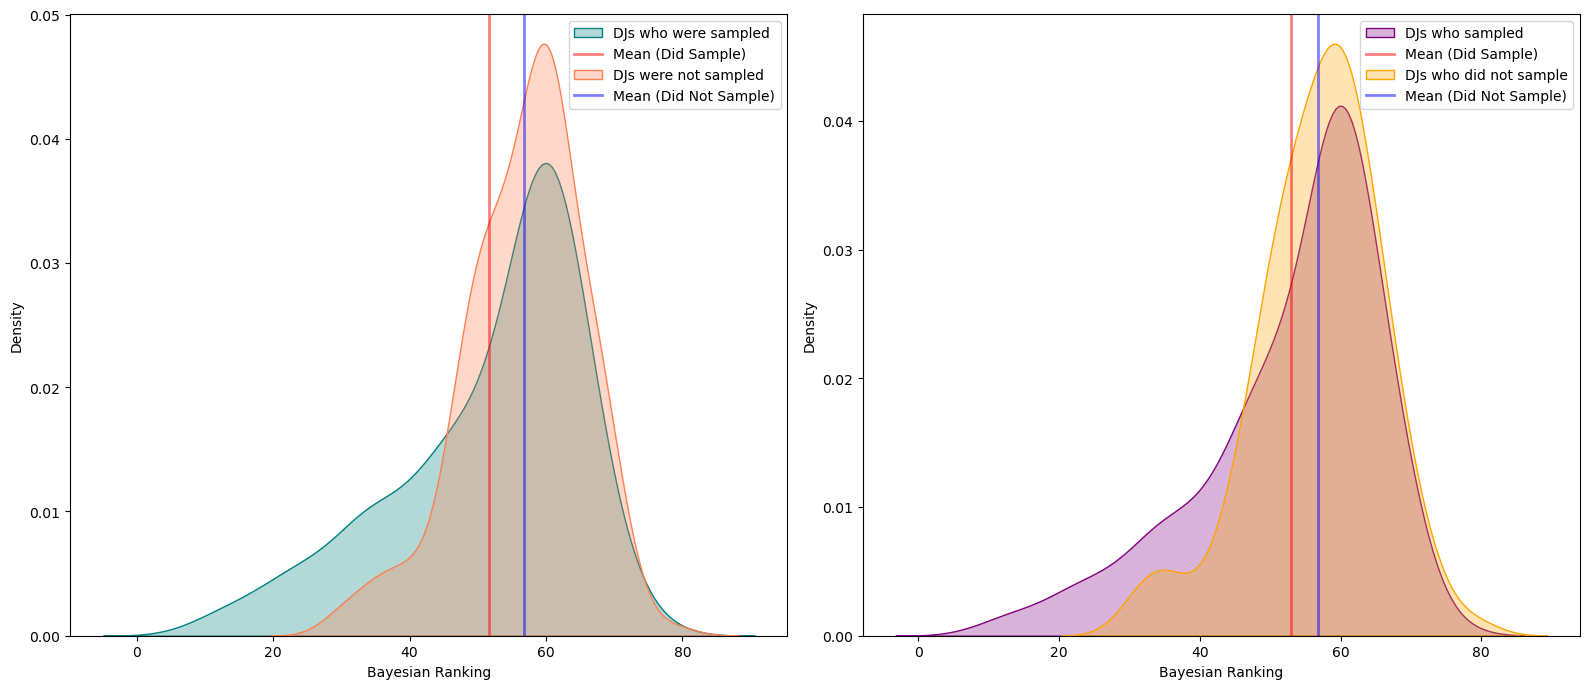

In [411]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a 1x2 grid for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: DJs who sampled vs. DJs who did not sample based on 'Num Sampled from'
sns.kdeplot(summary_raw_df[summary_raw_df['Num Sampled from'] != 0]['Bayesian Ranking'], 
            label='DJs who were sampled', fill=True, alpha=0.3, ax=axes[0],color='teal')
axes[0].axvline(x=summary_raw_df[summary_raw_df['Num Sampled from'] != 0]['Bayesian Ranking'].mean(), 
                linewidth=2, color='red', label="Mean (Did Sample)", alpha=0.5)
sns.kdeplot(summary_raw_df[summary_raw_df['Num Sampled from'] == 0]['Bayesian Ranking'], 
            label='DJs were not sampled', fill=True, alpha=0.3, ax=axes[0],color='coral')
axes[0].axvline(x=summary_raw_df[summary_raw_df['Num Sampled from'] == 0]['Bayesian Ranking'].mean(), 
                linewidth=2, color='blue', label="Mean (Did Not Sample)", alpha=0.5)
axes[0].legend()

# Plot 2: DJs who sampled vs. DJs who did not sample based on 'Num Sampled by'
sns.kdeplot(summary_raw_df[summary_raw_df['Num Sampled by'] != 0]['Bayesian Ranking'], 
            label='DJs who sampled', fill=True, alpha=0.3, ax=axes[1],color='purple')
axes[1].axvline(x=summary_raw_df[summary_raw_df['Num Sampled by'] != 0]['Bayesian Ranking'].mean(), 
                linewidth=2, color='red', label="Mean (Did Sample)", alpha=0.5)
sns.kdeplot(summary_raw_df[summary_raw_df['Num Sampled by'] == 0]['Bayesian Ranking'], 
            label='DJs who did not sample', fill=True, alpha=0.3, ax=axes[1],color='orange')
axes[1].axvline(x=summary_raw_df[summary_raw_df['Num Sampled by'] == 0]['Bayesian Ranking'].mean(), 
                linewidth=2, color='blue', label="Mean (Did Not Sample)", alpha=0.5)
axes[1].legend()

# Set a common xlabel for both plots
for ax in axes:
    ax.set_xlabel('Bayesian Ranking')

# Set a common ylabel for both plots
for ax in axes:
    ax.set_ylabel('Density')

# Show the plots
plt.tight_layout()

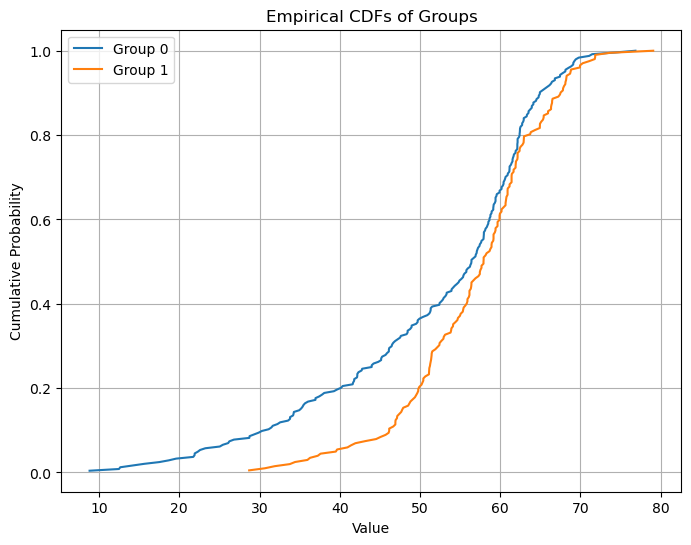

In [412]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf_0 = ECDF(data_category_0)
ecdf_1 = ECDF(data_category_1)

plt.figure(figsize=(8, 6))
plt.plot(ecdf_0.x, ecdf_0.y, label='Group 0')
plt.plot(ecdf_1.x, ecdf_1.y, label='Group 1')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('Empirical CDFs of Groups')
plt.legend()
plt.grid(True)
plt.show()

# Modeling Bayesian Ranking vs Sampling Amount 
- Skewed, 

In [492]:
summary_raw_df

,Unnamed: 0,DJ Name,Mean Ranking,Num Years,Num Sampled from,Num Sampled by,Bayesian Ranking
0,0,Tiësto,7.142857,21,53,43,12.485316
1,1,Paul van Dyk,29.714286,21,5,11,32.235316
2,2,Armin Van Buuren,2.952381,21,27,13,8.818649
3,3,Sasha,16.250000,8,11,2,25.422507
4,4,Ferry Corsten,47.285714,21,7,15,47.610316
...,...,...,...,...,...,...,...
441,441,Mau P,91.000000,1,6,2,60.161893
442,442,B Jones,94.000000,1,0,0,60.911893
443,443,Giuseppe Ottaviani,98.000000,1,0,2,61.911893
444,444,Faustix,99.000000,1,6,2,62.161893


In [573]:
#summary_raw_df[summary_raw_df[['DJ Name', 'Bayesian Ranking', 'Num Years', 'Num Sampled']]['Num Sampled'] != 0].to_csv("regression_data.csv")
data1 = summary_raw_df[summary_raw_df[['DJ Name', 'Bayesian Ranking', 'Num Years', 'Num Sampled from']]['Num Sampled from'] != 0]
data2 = summary_raw_df[summary_raw_df[['DJ Name', 'Bayesian Ranking', 'Num Years', 'Num Sampled by']]['Num Sampled by'] != 0]
data1.rename({"Num Sampled from": "Num Sampled"},axis=1,inplace=True)
data2.rename({"Num Sampled by": "Num Sampled"},axis=1,inplace=True)

/var/folders/f9/x6_f23z13z1dpfwmrmvqkhbm0000gn/T/ipykernel_40098/962248146.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.rename({"Num Sampled from": "Num Sampled"},axis=1,inplace=True)
/var/folders/f9/x6_f23z13z1dpfwmrmvqkhbm0000gn/T/ipykernel_40098/962248146.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2.rename({"Num Sampled by": "Num Sampled"},axis=1,inplace=True)


In [574]:
from scipy.stats import boxcox


data1['YJ Num Sampled'],lmbda1 = stats.yeojohnson(data1['Num Sampled'])
data2['YJ Num Sampled'],lmbda2 = stats.yeojohnson(data2['Num Sampled'])

/var/folders/f9/x6_f23z13z1dpfwmrmvqkhbm0000gn/T/ipykernel_40098/748561083.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['YJ Num Sampled'],lmbda1 = stats.yeojohnson(data1['Num Sampled'])
/var/folders/f9/x6_f23z13z1dpfwmrmvqkhbm0000gn/T/ipykernel_40098/748561083.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['YJ Num Sampled'],lmbda2 = stats.yeojohnson(data2['Num Sampled'])


R2 Score 0.14113135681712985
Beta (slope): -10.301778900684733
Intercept: 64.98065303391759
Correlation coefficient (r): -0.376
R^2 = 0.14113135681712974
P-value: 1.348e-09


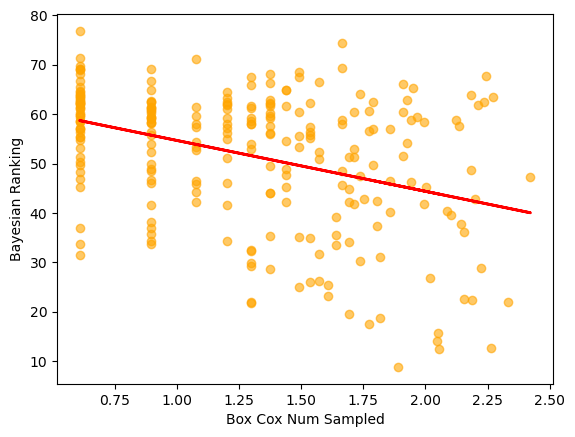

In [572]:
import numpy as np
import matplotlib.pyplot as plt

# Scatter plot with best-fit linear regression line
x= data['YJ Num Sampled']
y= data['Bayesian Ranking'] 
plt.scatter(x, y, color='orange', alpha=0.6)
# Fit linear regression line
coef = np.polyfit(x, y, 1)
y_fit = np.polyval(coef, x)
plt.figure(10,6)
plt.plot(x, y_fit, color='red', linewidth=2)
plt.xlabel('YJ Num Sampled From')
plt.ylabel('Bayesian Ranking')
r_value,p_value = pearsonr(x,y)
print("R2 Score",r2_score(y, y_fit))
print("Beta (slope):", coef[0])
print("Intercept:", coef[1])
print(f"Correlation coefficient (r): {r_value:.3f}")
print(f"R^2 = {r_value**2}")
print(f"P-value: {p_value:.3e}")

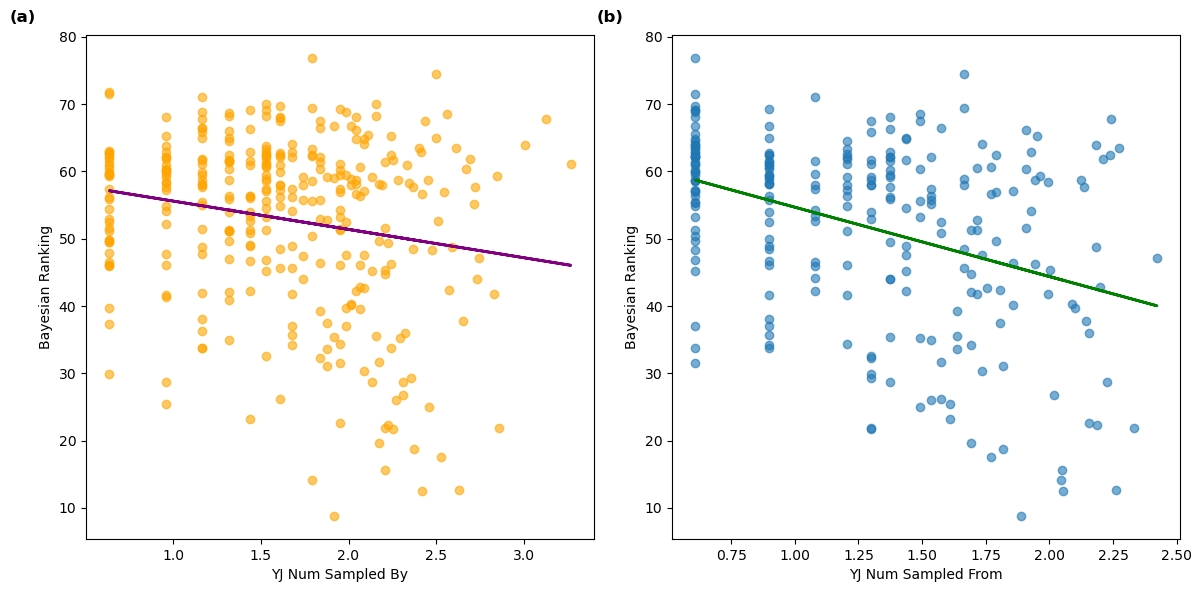

In [583]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assume you have your distributions as pandas Series or numpy arrays
# e.g., num_years_dist, num_sampled_from_dist, num_sampled_by_dist

# Create a figure with 3 subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(12,6))  # 1 row, 3 columns

# Plot each distribution using seaborn

x1= data1['YJ Num Sampled']
y1= data1['Bayesian Ranking'] 
axs[1].scatter(x1, y1, alpha=0.6)
# Fit linear regression line
coef = np.polyfit(x1, y1, 1)
y_fit = np.polyval(coef, x1)

axs[1].plot(x1, y_fit, color='green', linewidth=2)
axs[1].set_xlabel('YJ Num Sampled From')
axs[1].set_ylabel('Bayesian Ranking')
axs[1].text(-0.15, 1.05, '(b)', transform=axs[1].transAxes, fontsize=12, fontweight='bold', va='top')


x2= data2['YJ Num Sampled']
y2= data2['Bayesian Ranking'] 
axs[0].scatter(x2, y2, color='orange', alpha=0.6)
# Fit linear regression line
coef = np.polyfit(x2, y2, 1)
y_fit = np.polyval(coef, x2)

axs[0].plot(x2, y_fit, color='purple', linewidth=2)
axs[0].set_xlabel('YJ Num Sampled By')
axs[0].set_ylabel('Bayesian Ranking')
axs[0].text(-0.15, 1.05, '(a)', transform=axs[0].transAxes, fontsize=12, fontweight='bold', va='top')

# Adjust layout to avoid overlapping text
plt.tight_layout()

# Show the figure
plt.savefig("Regressions.png")

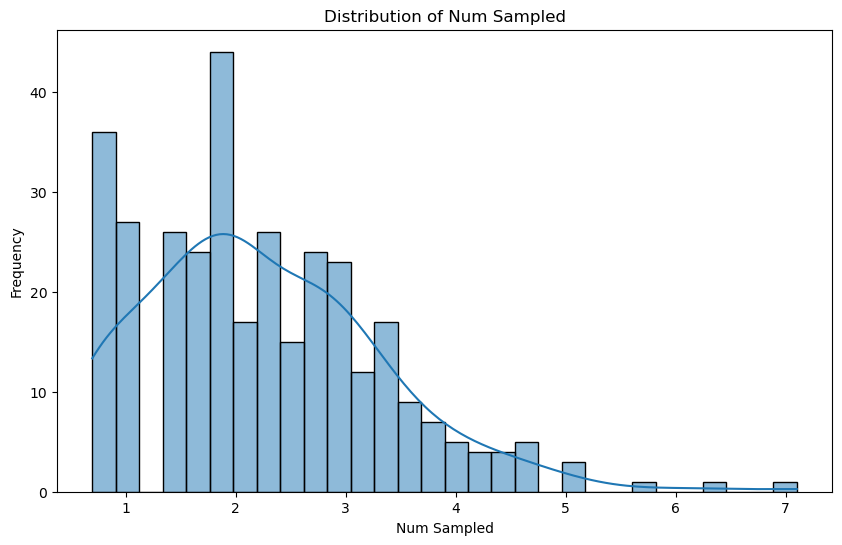

/Users/jasirnawar/miniforge3/envs/siloTest/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:6911: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
/Users/jasirnawar/miniforge3/envs/siloTest/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/jasirnawar/miniforge3/envs/siloTest/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:6902: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


Best fitting distribution for 'Num Sampled': norm
Parameters: (-2.1466547908160128e-16, 1.0)
KS Statistic: 0.06473700788521305
P-Value: 0.08759870993401553
transform: 2


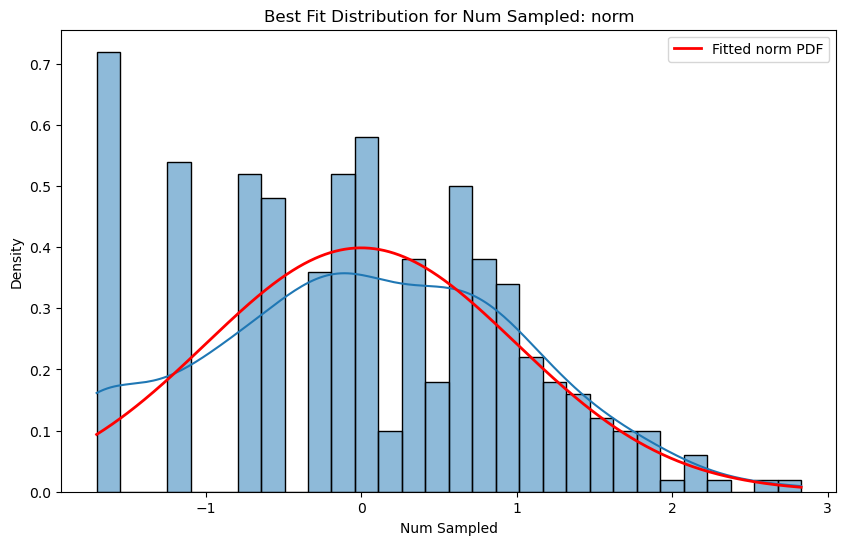

In [552]:
transforms = ['Sqrt Num Sampled', 'Box Cox Num Sampled', 'YJ Num Sampled', 'Log Num Sampled']
plt.figure(figsize=(10, 6))
sns.histplot(data[transforms[i]], bins=30, kde=True)
plt.title('Distribution of Num Sampled')
plt.xlabel('Num Sampled')
plt.ylabel('Frequency')
plt.show()
# Fit potential distributions
best_distribution = None
best_transform = None
best_params = None
best_ks_stat = float('inf')
best_p = 0
distributions = [stats.norm, stats.lognorm, stats.expon, stats.gamma, stats.weibull_min,stats.johnsonsu,stats.weibull_max]
for i in range(len(transforms)):
    for dist in distributions:
        params = dist.fit(data[transforms[i]])
        ks_stat, p_value = stats.kstest(data[transforms[i]], dist.name, args=params)
        if ks_stat < best_ks_stat:
            best_ks_stat = ks_stat
            best_distribution = dist
            best_params = params
            best_p = p_value
            best_transform = i

print(f"Best fitting distribution for 'Num Sampled': {best_distribution.name}")
print(f"Parameters: {best_params}")
print(f"KS Statistic: {best_ks_stat}")
print(f"P-Value: {p_value}")
print(f"transform: {best_transform}")

# Plot the best-fitting distribution
x = np.linspace(min(data[transforms[best_transform]]), max(data[transforms[best_transform]]), 1000)
fitted_pdf = best_distribution.pdf(x, *best_params)

plt.figure(figsize=(10, 6))
sns.histplot(data[transforms[best_transform]], bins=30, kde=True, stat='density')
plt.plot(x, fitted_pdf, 'r-', lw=2, label=f'Fitted {best_distribution.name} PDF')
plt.legend()
plt.title(f'Best Fit Distribution for Num Sampled: {best_distribution.name}')
plt.xlabel('Num Sampled')
plt.ylabel('Density')
plt.show()


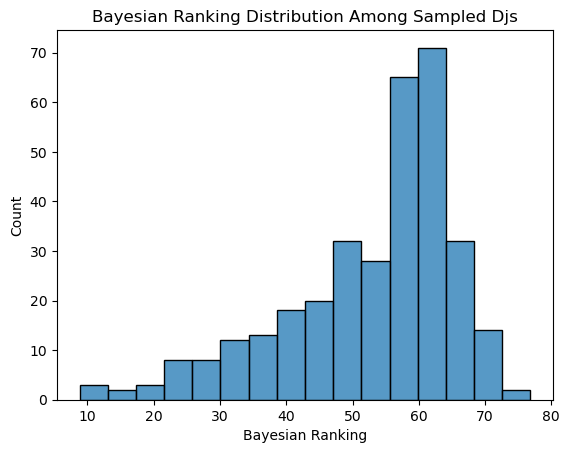

In [553]:
sns.histplot(data=data,x='Bayesian Ranking')
plt.title("Bayesian Ranking Distribution Among Sampled Djs")
plt.savefig("BR_Sampled_Dist.png")

<Axes: xlabel='Box Cox Num Sampled', ylabel='Count'>

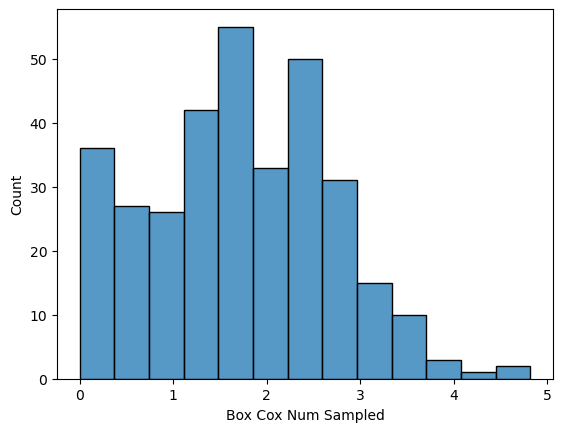

In [554]:
sns.histplot(data=data,x='Box Cox Num Sampled')

In [555]:
data['Box Cox Num Years'], box_cox_lambda_param_years = boxcox(data['Num Years'])
data['Log Num Years'] = np.log1p(data['Num Years'])
data['YJ Num Years'] = pt.fit_transform(data['Num Years'].values.reshape(-1, 1))

data['Box Cox Num Sampled'], box_cox_lambda_param_years = stats.boxcox(data['Num Sampled'])
data['Log Num Sampled'] = np.log1p(data['Num Sampled'])
data['YJ Num Sampled'],lmbda = stats.yeojohnson(data['Num Sampled'])

data['Box Cox Bayesian Ranking'], box_cox_lambda_param_years = boxcox(data['Bayesian Ranking'])
data['Log Bayesian Ranking'] = np.log1p(data['Bayesian Ranking'])
data['YJ Bayesian Ranking'] = pt.fit_transform(data['Bayesian Ranking'].values.reshape(-1, 1))

/var/folders/f9/x6_f23z13z1dpfwmrmvqkhbm0000gn/T/ipykernel_40098/749206566.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Box Cox Num Years'], box_cox_lambda_param_years = boxcox(data['Num Years'])
/var/folders/f9/x6_f23z13z1dpfwmrmvqkhbm0000gn/T/ipykernel_40098/749206566.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Log Num Years'] = np.log1p(data['Num Years'])
/var/folders/f9/x6_f23z13z1dpfwmrmvqkhbm0000gn/T/ipykernel_40098/749206566.py:3: SettingWithCopyWarning: 
A value is trying 

In [557]:
lmbda

-0.2565130295038599

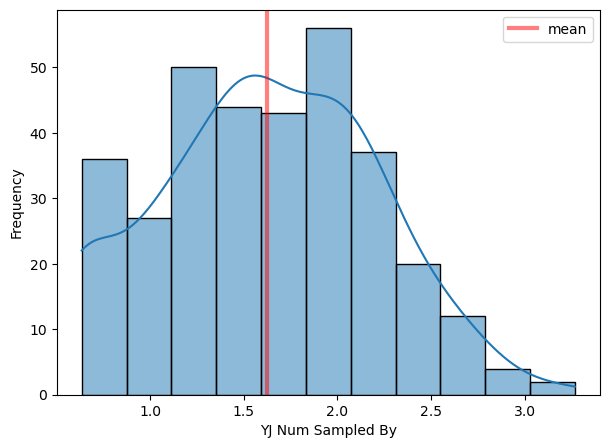

In [558]:
plt.figure(figsize=(7, 5))
sns.histplot(data=data,x='YJ Num Sampled',kde=True)
plt.axvline(x=data['YJ Num Sampled'].mean(), linewidth=3, color='r', label="mean", alpha=0.5)
plt.ylabel('Frequency')
plt.xlabel('YJ Num Sampled By')
plt.legend()
plt.savefig("figures/Sampled_By_TS_Distribution.png")

In [559]:
lmbda

-0.2565130295038599

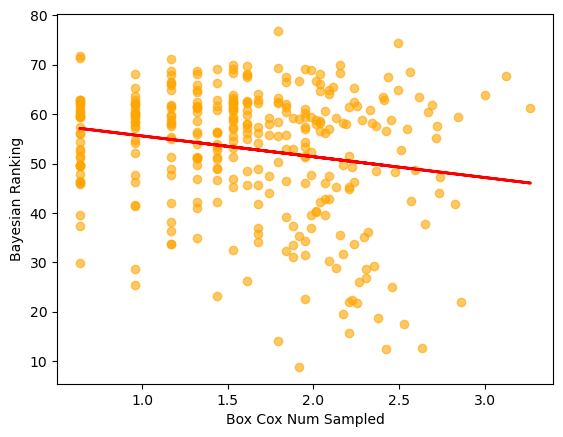

R2 Score 0.03634369355464295
Beta (slope): -4.2086139969518666
Intercept: 59.79625631917356
Correlation coefficient (r): -0.375
R^2 = 0.14061741531973243
P-value: 8.760e-02


In [560]:
import numpy as np
import matplotlib.pyplot as plt

# Scatter plot with best-fit linear regression line
x= data['YJ Num Sampled']
y= data['Bayesian Ranking'] 
plt.scatter(x, y, color='orange', alpha=0.6)
# Fit linear regression line
coef = np.polyfit(x, y, 1)
y_fit = np.polyval(coef, x)
plt.plot(x, y_fit, color='red', linewidth=2)
plt.xlabel('Box Cox Num Sampled')
plt.ylabel('Bayesian Ranking')
plt.show()

print("R2 Score",r2_score(y, y_fit))
print("Beta (slope):", coef[0])
print("Intercept:", coef[1])
print(f"Correlation coefficient (r): {r_value:.3f}")
print(f"R^2 = {r_value**2}")
print(f"P-value: {p_value:.3e}")

In [184]:
from sklearn.metrics import r2_score
yhat = model.predict(X)
print(r2_score(y,yhat))

0.5453335261296317


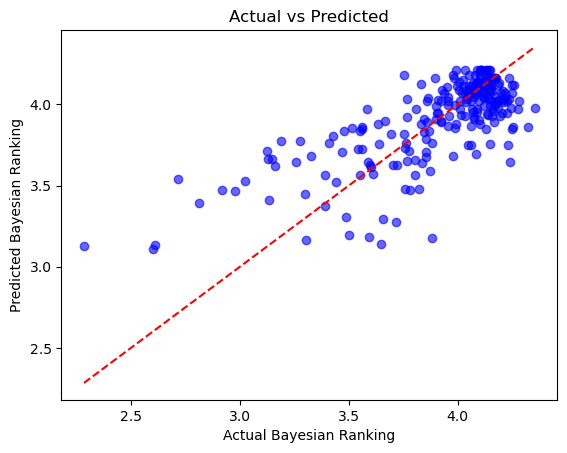

In [185]:
import matplotlib.pyplot as plt

plt.scatter(y, yhat, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('Actual Bayesian Ranking')
plt.ylabel('Predicted Bayesian Ranking')
plt.title('Actual vs Predicted')
plt.show()


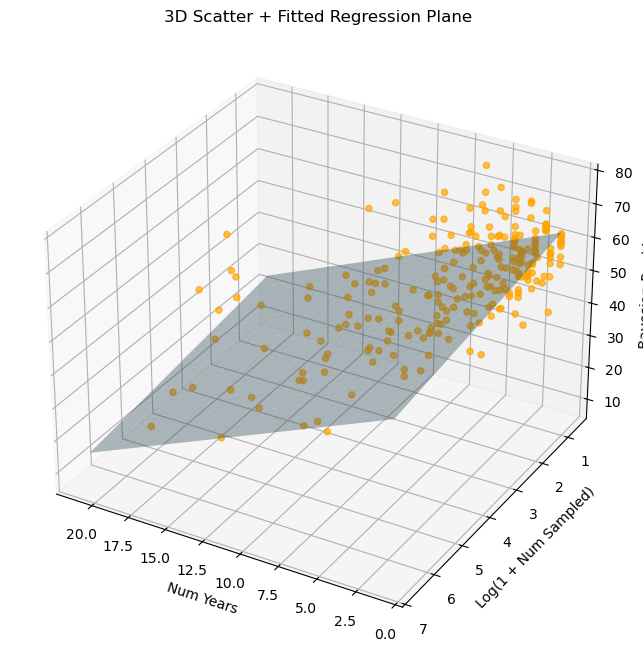

In [193]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn.linear_model import LinearRegression

# Prepare the data
X = data['Num Years']
Y = data['Log Num Sampled']
Z = data['Bayesian Ranking']

# Combine independent variables into one matrix
X_full = np.column_stack((X, Y))

# Fit the linear regression model
model = LinearRegression()
model.fit(X_full, Z)

# 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter the points
ax.scatter(X.values.flatten(), Y, Z, c='orange', alpha=0.7)

# Create a meshgrid for plotting the surface
x_surf = np.linspace(X.min(), X.max(), 30)  # 30 points between min and max of Num Years
y_surf = np.linspace(Y.min(), Y.max(), 30)  # 30 points for Log Num Sampled
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# Flatten and predict Z for the surface
xy_mesh = np.column_stack((x_surf.ravel(), y_surf.ravel()))
z_surf = model.predict(xy_mesh)
z_surf = z_surf.reshape(x_surf.shape)

# Plot the regression surface
ax.plot_surface(x_surf, y_surf, z_surf, color='skyblue', alpha=0.4, edgecolor='none')

# Labels
ax.set_xlabel('Num Years')
ax.set_ylabel('Log(1 + Num Sampled)')
ax.set_zlabel('Bayesian Ranking')
ax.set_title('3D Scatter + Fitted Regression Plane')

# Optional: better viewing angle
ax.view_init(elev=30, azim=120)

plt.show()


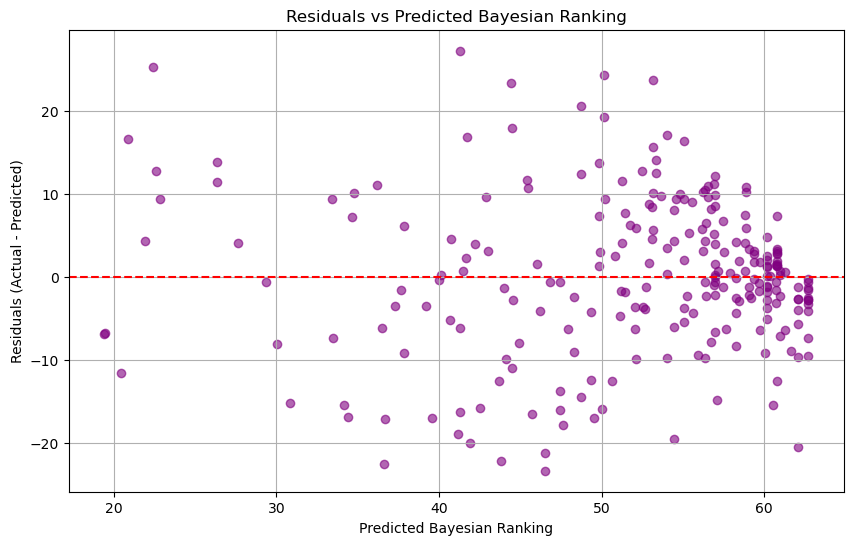

In [194]:
import matplotlib.pyplot as plt

# Prepare data again
X = data['Num Years']
Y = data['Log Num Sampled']
Z_actual = data['Bayesian Ranking']
X_full = np.column_stack((X, Y))

# Get predictions
Z_pred = model.predict(X_full)

# Calculate residuals
residuals = Z_actual - Z_pred

# 2D Residual Plot
plt.figure(figsize=(10, 6))
plt.scatter(Z_pred, residuals, color='purple', alpha=0.6)

# Plot a horizontal line at 0
plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Predicted Bayesian Ranking')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Bayesian Ranking')
plt.grid(True)
plt.show()


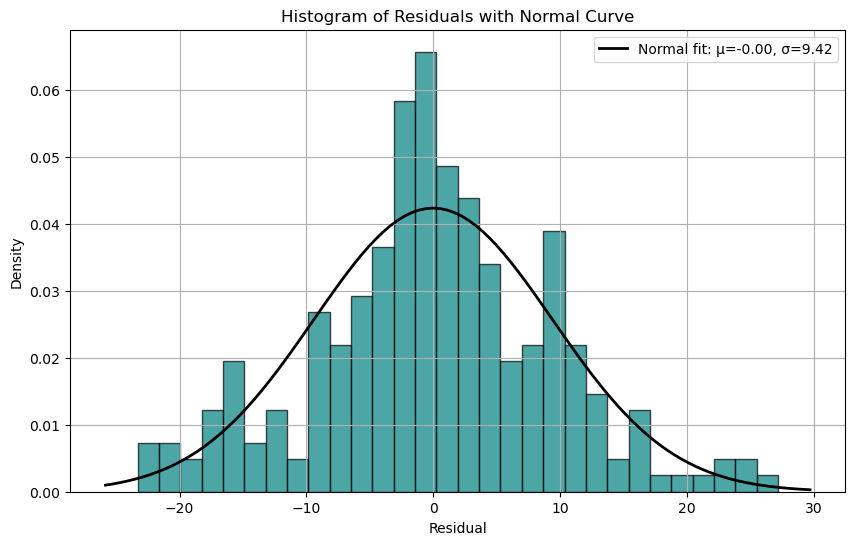

In [195]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
# Set up the plot
plt.figure(figsize=(10, 6))

# Plot the histogram
count, bins, ignored = plt.hist(residuals, bins=30, density=True, color='teal', edgecolor='black', alpha=0.7)

# Fit a normal distribution and plot the PDF
mu, std = norm.fit(residuals)  # Mean and standard deviation
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot the fitted normal curve
plt.plot(x, p, 'k', linewidth=2, label=f'Normal fit: μ={mu:.2f}, σ={std:.2f}')

# Labels and title
plt.xlabel('Residual')
plt.ylabel('Density')
plt.title('Histogram of Residuals with Normal Curve')
plt.legend()
plt.grid(True)
plt.show()


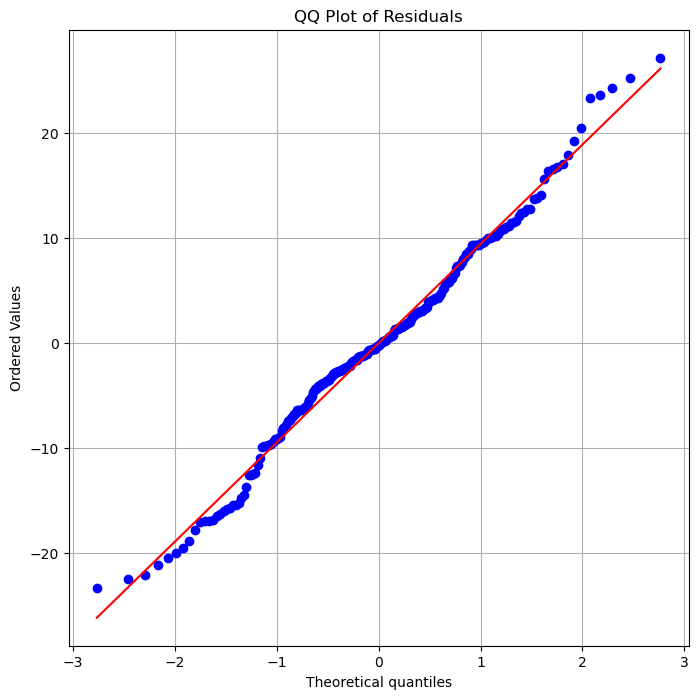

In [196]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# QQ-plot of residuals
plt.figure(figsize=(8, 8))
stats.probplot(residuals, dist="norm", plot=plt)

plt.title('QQ Plot of Residuals')
plt.grid(True)
plt.show()


In [197]:
from scipy.stats import kstest
from scipy.stats import shapiro
# Standardize residuals (important before KS test for normality)
residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)

# KS test
ks_stat, p_value = kstest(residuals_std, 'norm')

print(f'KS Statistic: {ks_stat:.4f}')
print(f'p-value: {p_value:.4f}')


# Shapiro-Wilk test
shapiro_stat, shapiro_p = shapiro(residuals)

print(f'Shapiro-Wilk Statistic: {shapiro_stat:.4f}')
print(f'Shapiro-Wilk p-value: {shapiro_p:.4f}')


KS Statistic: 0.0594
p-value: 0.3429
Shapiro-Wilk Statistic: 0.9891
Shapiro-Wilk p-value: 0.0630
